In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point
import gstools as gs

In [2]:
pd.set_option('display.max_columns', None)

senate_general_indiv20 = pd.read_csv('../data/senate_general_indiv20.csv', dtype=str)
senate_general_indiv22 = pd.read_csv('../data/senate_general_indiv22.csv', dtype=str)

senate_general_indiv20['TRANSACTION_AMT'] = senate_general_indiv20['TRANSACTION_AMT'].astype(int)
senate_general_indiv22['TRANSACTION_AMT'] = senate_general_indiv22['TRANSACTION_AMT'].astype(int)

display(senate_general_indiv20.head())
display(senate_general_indiv22.head())

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00647842,202010089285059826,15,"LOMBARDO, ROBERT",MANCHESTER,NH,03102,ELECTRONICS FOR IMAGING INC,TRADE COMPLIANCE MANAGER,2020-09-08,275,S0NH00300,"O'DONNELL, JUSTIN F",LIB,NH
1,C00716340,202010089285059649,15,"FLOYD, WILLIAM",EVANSTON,IL,60201,RETIRED,RETIRED,2020-09-10,500,S0IL00543,"CURRAN, MARK",REP,IL
2,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,1000,S0IL00543,"CURRAN, MARK",REP,IL
3,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,250,S0IL00543,"CURRAN, MARK",REP,IL
4,C00716340,202010089285059661,15,"O'BRIEN, KATHLEEN",LAKE FOREST,IL,60045,SELF,ATTORNEY,2020-09-02,250,S0IL00543,"CURRAN, MARK",REP,IL


,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00588772,202212089547742689,22Y,"MURPHY, PAMELA",STAMFORD,CT,069028004,NaN,NaN,2022-09-16,2900,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
1,C00588772,202212089547734268,15,"BRIODY, ELIZABETH",DETROIT,MI,482325170,CULTURAL KEYS LLC,BUSINESS ANTHROPOLOGIST,2022-09-16,200,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
2,C00588772,202212089547736565,15E,"WORKMAN, LINDA",NAPERVILLE,IL,605646011,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,50,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
3,C00588772,202212089547736566,15E,"FRIEDELL, MORRIS",BERKELEY,CA,947101522,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,1000,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
4,C00588772,202212089547739541,15E,"OWENS, NORMAN",EDINA,MN,554102732,UNISYS,IT CONSULTANT,2022-09-16,10,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH


In [3]:
# aggregate by zip code
agg20 = senate_general_indiv20.groupby('ZIP_CODE')['TRANSACTION_AMT'].sum().reset_index()
agg22 = senate_general_indiv22.groupby('ZIP_CODE')['TRANSACTION_AMT'].sum().reset_index()

In [4]:
# merge the two dataframes on ZIP_CODE
agg = pd.merge(agg20, agg22, on='ZIP_CODE', how='outer', suffixes=('_20', '_22')).fillna(0)

In [5]:
# import first three columns of ../data/uszips.csv, display first row as five digit strings
uszips = pd.read_csv('../data/uszips.csv', usecols=['zip', 'lat', 'lng'])
uszips['zip'] = uszips['zip'].astype(str).str.zfill(5)
display(uszips.head())

# merge agg with uszips on ZIP_CODE and zip, remove rows in agg that do not have a match in uszips
agg = pd.merge(agg, uszips, left_on='ZIP_CODE', right_on='zip', how='inner')
agg = agg.drop(columns=['zip'])

agg["TRANSACTION_AMT_20"] = agg["TRANSACTION_AMT_20"].apply(lambda x: max(0, x))
agg["TRANSACTION_AMT_22"] = agg["TRANSACTION_AMT_22"].apply(lambda x: max(0, x))

agg["delta_log"] = np.log(agg['TRANSACTION_AMT_22'] + 1) - np.log(agg['TRANSACTION_AMT_20'] + 1)

agg["total"] = agg["TRANSACTION_AMT_20"] + agg["TRANSACTION_AMT_22"]
agg = agg[agg["total"] >= 50].copy()

,zip,lat,lng
0,00601,18.18027,-66.75266
1,00602,18.36075,-67.17541
2,00603,18.45744,-67.12225
3,00606,18.16585,-66.93716
4,00610,18.29110,-67.12243


In [6]:
gdf = gpd.GeoDataFrame(
    agg,
    geometry=gpd.points_from_xy(agg["lng"], agg["lat"]),
    crs="EPSG:4326"
)

# use a US projection (meters)
gdf = gdf.to_crs("EPSG:5070")  # NAD83 / Conus Albers

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
values = gdf["delta_log"].values

In [7]:
coords.shape

(18150, 2)

In [19]:
coords_temp = coords[:5000,:2]
values_temp = values[:5000]

In [27]:
maxlag = 1_000_000   # 1000 km
n_lags = 15

bin_edges = np.linspace(0, maxlag, n_lags + 1)

bin_center, gamma, counts = gs.vario_estimate(
    (coords[:,0], coords[:,1]),
    values,
    bin_edges=bin_edges,
    return_counts=True
)

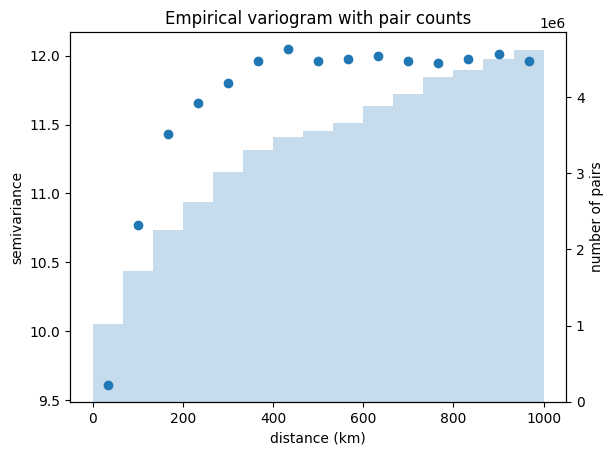

In [28]:
fig, ax1 = plt.subplots()

ax1.scatter(bin_center / 1000, gamma, label="empirical")
ax1.set_xlabel("distance (km)")
ax1.set_ylabel("semivariance")

ax2 = ax1.twinx()
ax2.bar(bin_center / 1000, counts, alpha=0.25, width=(maxlag / n_lags) / 1000)
ax2.set_ylabel("number of pairs")

plt.title("Empirical variogram with pair counts")
plt.show()

In [29]:
model = gs.Spherical(dim=2)
model.fit_variogram(bin_center, gamma)

print("range:", model.len_scale)
print("sill:", model.var)
print("nugget:", model.nugget)

range: 275537.394217136
sill: 2.7573289736340407
nugget: 9.196906830662154
